Setup & Data Fetching - Xiulin/Taroko Region
Bounding Box: [121.4, 24.1, 121.8, 24.25]

Trying Phase 1: 4/15-5/31, cc<20%...
  → Found 0 scenes
Trying Phase 2: 4/3-8/31, cc<30%...
  → Found 10 scenes

=== Selected Scene ===
  Scene ID    : S2A_MSIL2A_20240827T022531_R046_T51QUG_20240827T053853
  Date        : 2024-08-27 02:25:31
  Cloud Cover : 8.4%
  Platform    : Sentinel-2A
✓ All required bands available

Loading data with stackstac...
Lazy array shape: (1, 7, 852, 2041) (time, band, y, x)
Computing data...
Data loaded successfully!
Shape: (7, 852, 2041)

Preprocessing - Cloud Mask & Reflectance Conversion

=== SCL Cloud Mask ===
  Cloud/Shadow/Snow pixels: 145,051 / 1,738,932 (8.3%)

Image shape: (6, 852, 2041) (bands, height, width)
Pixel size: 20m x 20m
Image dimensions: 40.8 km x 17.0 km
Valid pixel ratio (after cloud mask): 91.7%

=== Band Statistics ===
  Blue   (B02): min=0.0948, max=0.9848, mean=0.1611
  Green  (B03): min=0.0905, max=0.9912, mean=0.1750
  Red    (B04): min=0

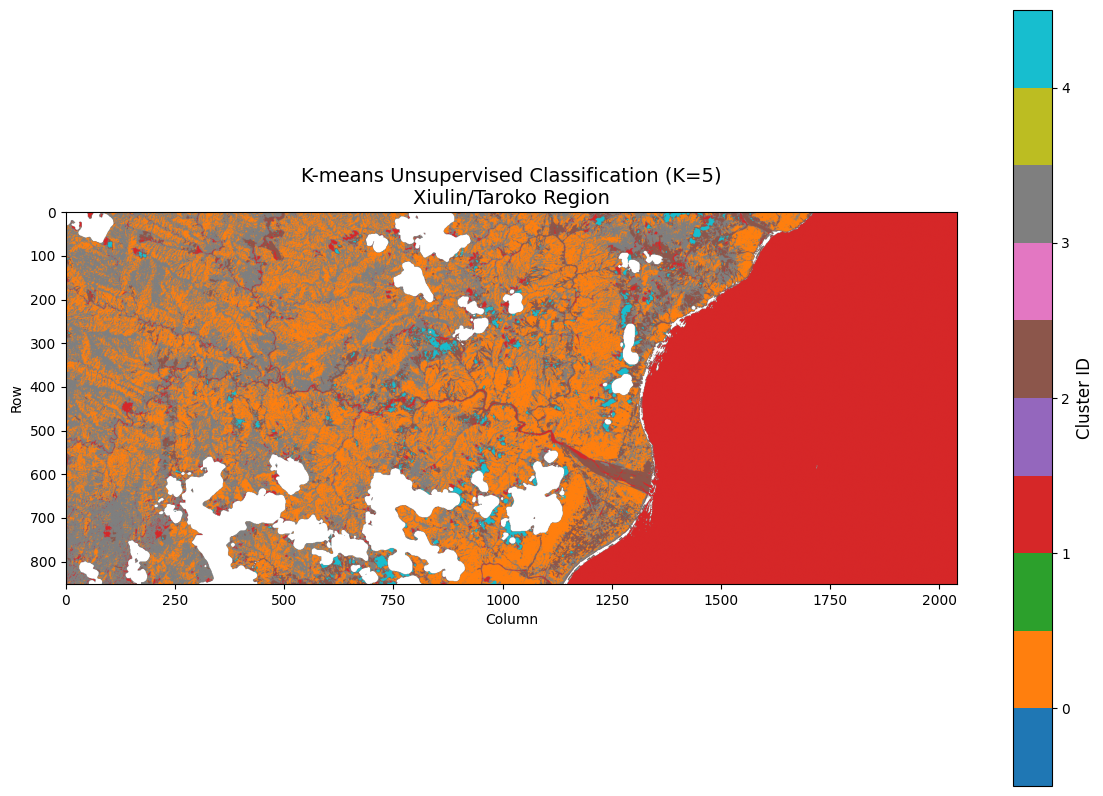


=== Cluster Statistics ===
  Cluster 0:  445,400 pixels (27.9%)
  Cluster 1:  584,806 pixels (36.7%)
  Cluster 2:  108,071 pixels (6.8%)
  Cluster 3:  434,863 pixels (27.3%)
  Cluster 4:   20,683 pixels (1.3%)

Mean Reflectance Values for Each Cluster

Cluster          Blue      Green        Red        NIR      SWIR1      SWIR2 
----------------------------------------------------------------------------
0              0.1276     0.1595     0.1305     0.5301     0.3110     0.1920 
1              0.1903     0.1825     0.1709     0.1688     0.1682     0.1570 
2              0.2380     0.2585     0.2557     0.3675     0.3577     0.2887 
3              0.1245     0.1478     0.1285     0.4122     0.2772     0.1808 
4              0.4247     0.4349     0.4309     0.5257     0.5145     0.4373 


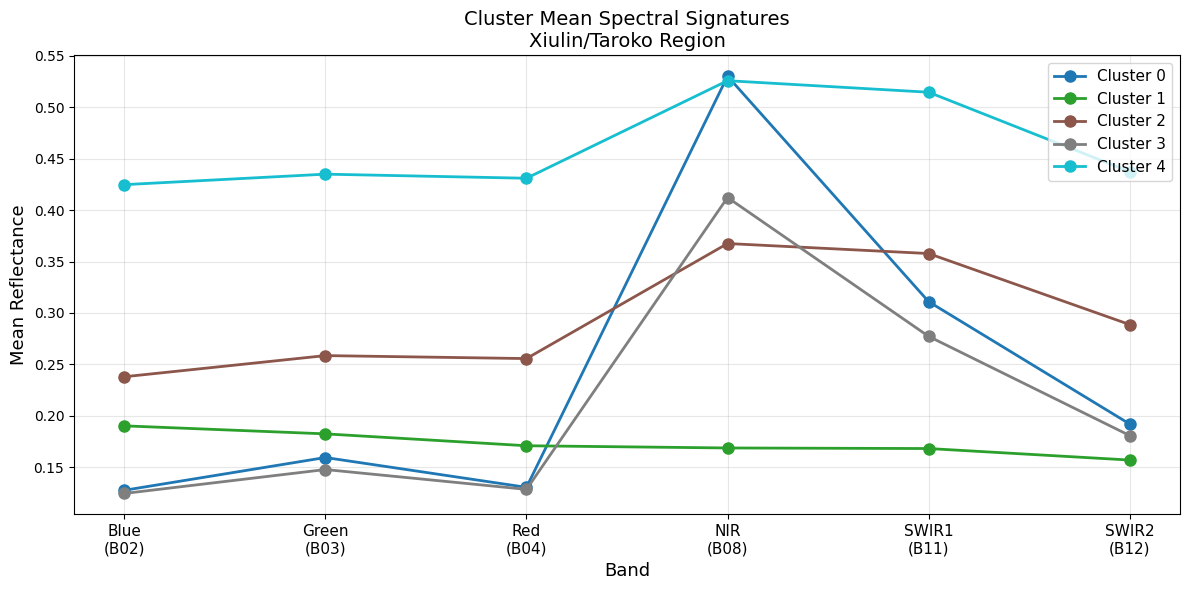


Task 1 Completed Successfully!

Spectral Interpretation Guide:
  - High NIR, Low Red → Healthy Vegetation
  - Low in all bands → Water
  - High Red/SWIR → Bare Soil / Landslide
  - Overall bright → Built-up / Artificial surfaces

Use the spectral signatures above to manually label each cluster.


In [1]:
%run week12_kmeans_taroko.py

{'森林': 0, '水體': 1, '裸露地': 2, '農地': 3, '建物': 4}

Loading Sentinel-2 Image Data
Trying Phase 1: 4/15-5/31, cc<20%...
  → Found 0 scenes
Trying Phase 2: 4/3-8/31, cc<30%...
  → Found 10 scenes

Selected Scene: S2A_MSIL2A_20240827T022531_R046_T51QUG_20240827T053853
Date: 2024-08-27
Cloud Cover: 8.4%
Loading data...
Image shape: (6, 852, 2041)
Image CRS: EPSG:32651

Task 2: Random Forest Supervised Classification

Step 1: Parse KML and Rasterize Training Samples
------------------------------------------------------------
Found 15 Placemarks in KML
  ✓ '水體' → Class 1 (Water)
  ✓ '水體' → Class 1 (Water)
  ✓ '森林' → Class 0 (Forest)
  ✓ '森林' → Class 0 (Forest)
  ✓ '森林' → Class 0 (Forest)
  ✓ '裸露地' → Class 2 (Bare Soil)
  ✓ '裸露地' → Class 2 (Bare Soil)
  ✓ '裸露地' → Class 2 (Bare Soil)
  ✓ '農地' → Class 3 (Agriculture)
  ✓ '農地' → Class 3 (Agriculture)
  ✓ '農地' → Class 3 (Agriculture)
  ✓ '農地' → Class 3 (Agriculture)
  ✓ '建物' → Class 4 (Built-up)
  ✓ '建物' → Class 4 (Built-up)
  ✓ '建物' → Class 4 (Built-up)

Valid polygons extracted: 15

GeoDataFram

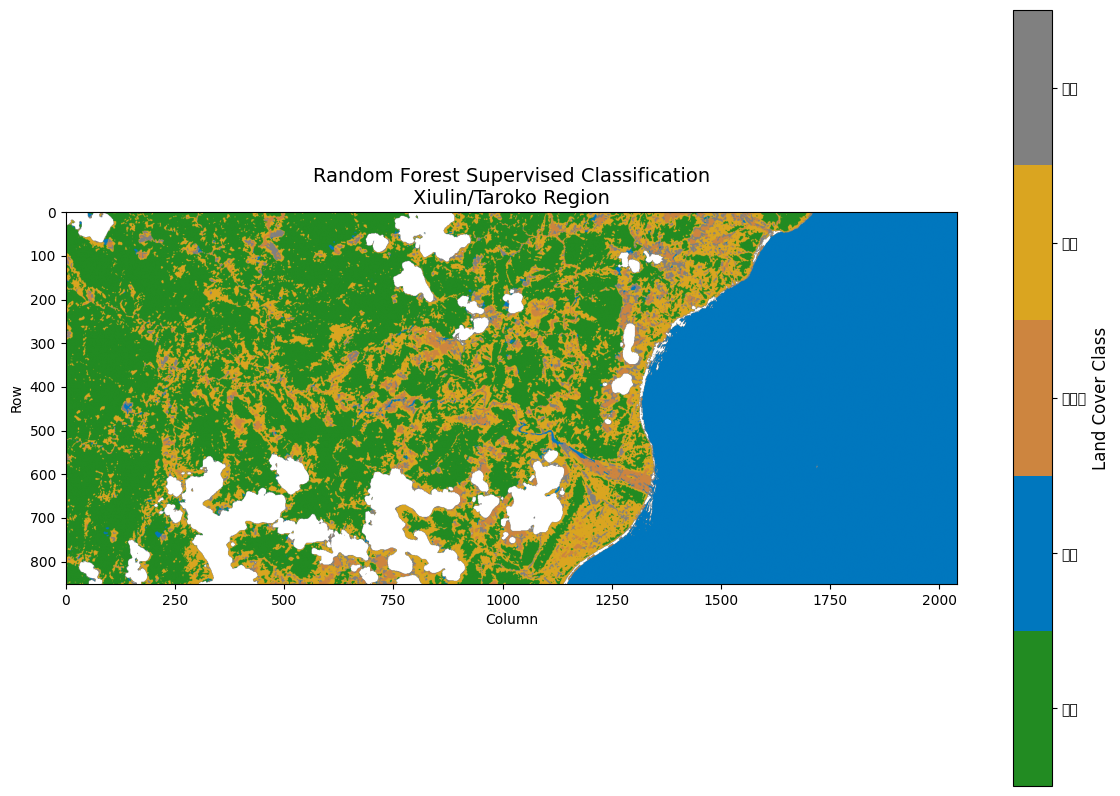


Step 7: Feature Importance
------------------------------------------------------------


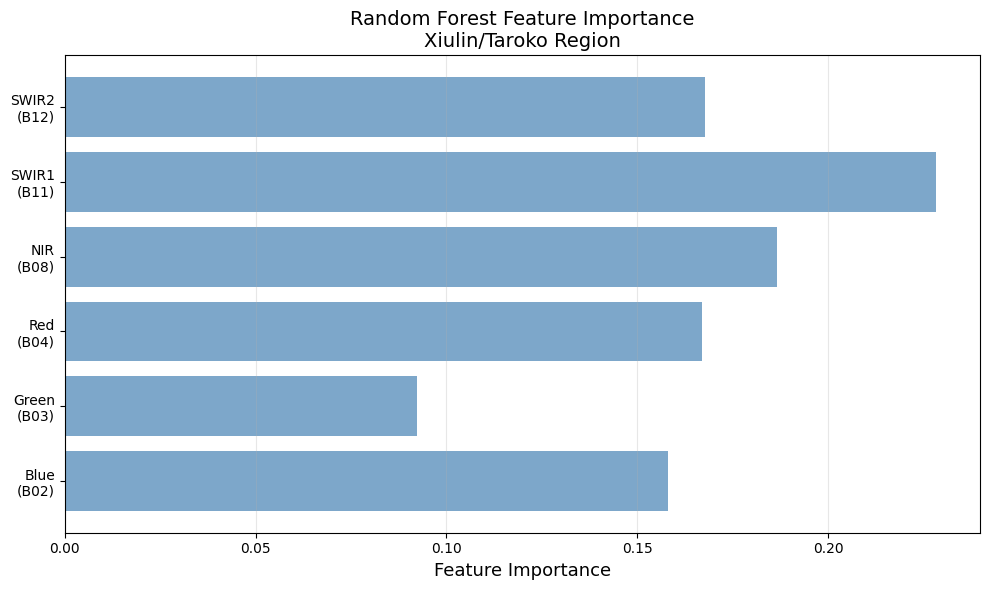


Feature Importance:
  Blue   (B02): 0.1582
  Green  (B03): 0.0924
  Red    (B04): 0.1669
  NIR    (B08): 0.1865
  SWIR1  (B11): 0.2284
  SWIR2  (B12): 0.1676

Task 2 Completed Successfully!


In [2]:
%run week12_randomforest_taroko.py

### 哪個波段最重要？為什麼？
- SWIR1 (B11) 的統治力：本次任務的核心是災後地貌（特別是崩塌地）的辨識。SWIR 對「水分」與「土壤/岩石礦物」極度敏感。當原本覆蓋植被的山坡崩塌後，地表從「富含水分的樹冠」變成「乾燥的土石開挖面」，B11 能極其敏銳地捕捉到這個巨變。同時，它也能完美區分會強烈吸收 SWIR 的「水體/陰影」與高反射的「裸地/建物」。

Task 3A: Internal Accuracy Metrics

Step 1: Predict on Test Set
------------------------------------------------------------
Test set predictions completed: 146 samples

Step 2: Generate Confusion Matrix
------------------------------------------------------------
Confusion matrix shape: (5, 5)


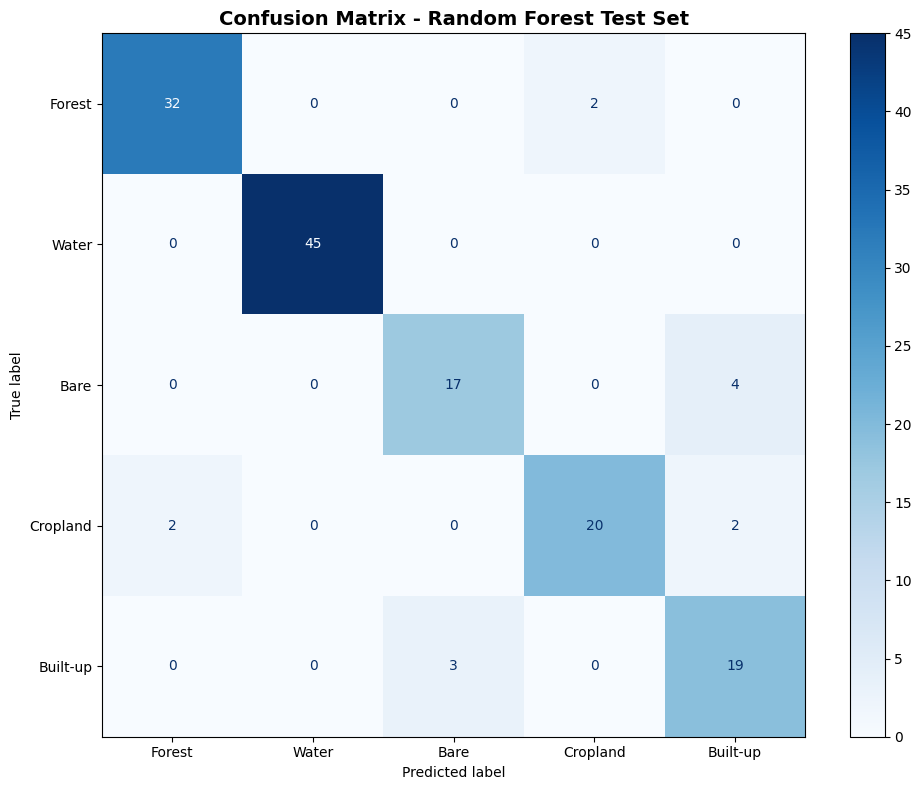


Step 3: Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

      Forest     0.9412    0.9412    0.9412        34
       Water     1.0000    1.0000    1.0000        45
        Bare     0.8500    0.8095    0.8293        21
    Cropland     0.9091    0.8333    0.8696        24
    Built-up     0.7600    0.8636    0.8085        22

    accuracy                         0.9110       146
   macro avg     0.8921    0.8895    0.8897       146
weighted avg     0.9136    0.9110    0.9114       146


Step 4: Model Performance Summary
------------------------------------------------------------

Accuracy Comparison:
  Training Accuracy : 1.0000 (100.00%)
  Test Accuracy     : 0.9110 (91.10%)
  OOB Score         : 0.9331 (93.31%)

Interpretation:
  - OOB is an unbiased estimate of generalization error
  - OOB vs Test difference: 0.0221
    → Excellent agreement, model is robust

Task 3A Completed!


In [5]:
# =============================================================================
# Task 3A: Internal Accuracy Metrics
# =============================================================================

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import os

print("=" * 60)
print("Task 3A: Internal Accuracy Metrics")
print("=" * 60)

# 1. Predict on test set
print("\nStep 1: Predict on Test Set")
print("-" * 60)

y_pred_test = rf.predict(X_test)

print(f"Test set predictions completed: {len(y_pred_test)} samples")

# 2. Generate and plot confusion matrix
print("\nStep 2: Generate Confusion Matrix")
print("-" * 60)

cm = confusion_matrix(y_test, y_pred_test)
print(f"Confusion matrix shape: {cm.shape}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Forest', 'Water', 'Bare', 'Cropland', 'Built-up']
)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix - Random Forest Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
fig.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

# 3. Classification report
print("\nStep 3: Classification Report")
print("-" * 60)

class_names_report = ['Forest', 'Water', 'Bare', 'Cropland', 'Built-up']
report = classification_report(y_test, y_pred_test, target_names=class_names_report, digits=4)
print(report)

# 4. OOB Score and comparison
print("\nStep 4: Model Performance Summary")
print("-" * 60)

test_accuracy = accuracy_score(y_test, y_pred_test)
oob_score = rf.oob_score_
train_accuracy = accuracy_score(y_train, rf.predict(X_train))

print(f"\nAccuracy Comparison:")
print(f"  Training Accuracy : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Test Accuracy     : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  OOB Score         : {oob_score:.4f} ({oob_score*100:.2f}%)")
print(f"\nInterpretation:")
print(f"  - OOB is an unbiased estimate of generalization error")
print(f"  - OOB vs Test difference: {abs(oob_score - test_accuracy):.4f}")
if abs(oob_score - test_accuracy) < 0.05:
    print(f"    → Excellent agreement, model is robust")
elif abs(oob_score - test_accuracy) < 0.10:
    print(f"    → Good agreement, model generalizes well")
else:
    print(f"    → Moderate difference, monitor for overfitting")

print("\n" + "=" * 60)
print("Task 3A Completed!")
print("=" * 60)


Task 3B: Independent Validation - SWCB Data

Step 1: Parse SWCB KML File
------------------------------------------------------------
✓ SWCB KML parsed successfully
  Total landslide polygons: 1335
  CRS: EPSG:4326

Step 2: Clip SWCB Polygons to Study Area Extent
------------------------------------------------------------
Clipped polygons within study area: 207
Total area: 8.16e-05 m²
Reprojected to: EPSG:32651

Step 3: Rasterize SWCB Polygons
------------------------------------------------------------
✓ SWCB mask created
  Shape: (852, 2041)
  Landslide pixels: 4011
  Non-landslide pixels: 1734921

Step 4: Extract RF Bare/Landslide Class
------------------------------------------------------------
RF landslide mask created
  Shape: (852, 2041)
  Predicted landslide pixels: 45169

Step 5: Calculate Spatial Overlap Metrics
------------------------------------------------------------

Confusion Matrix (Landslide Detection):
  True Positives (TP)  : 400
  False Negatives (FN) : 3,611
 

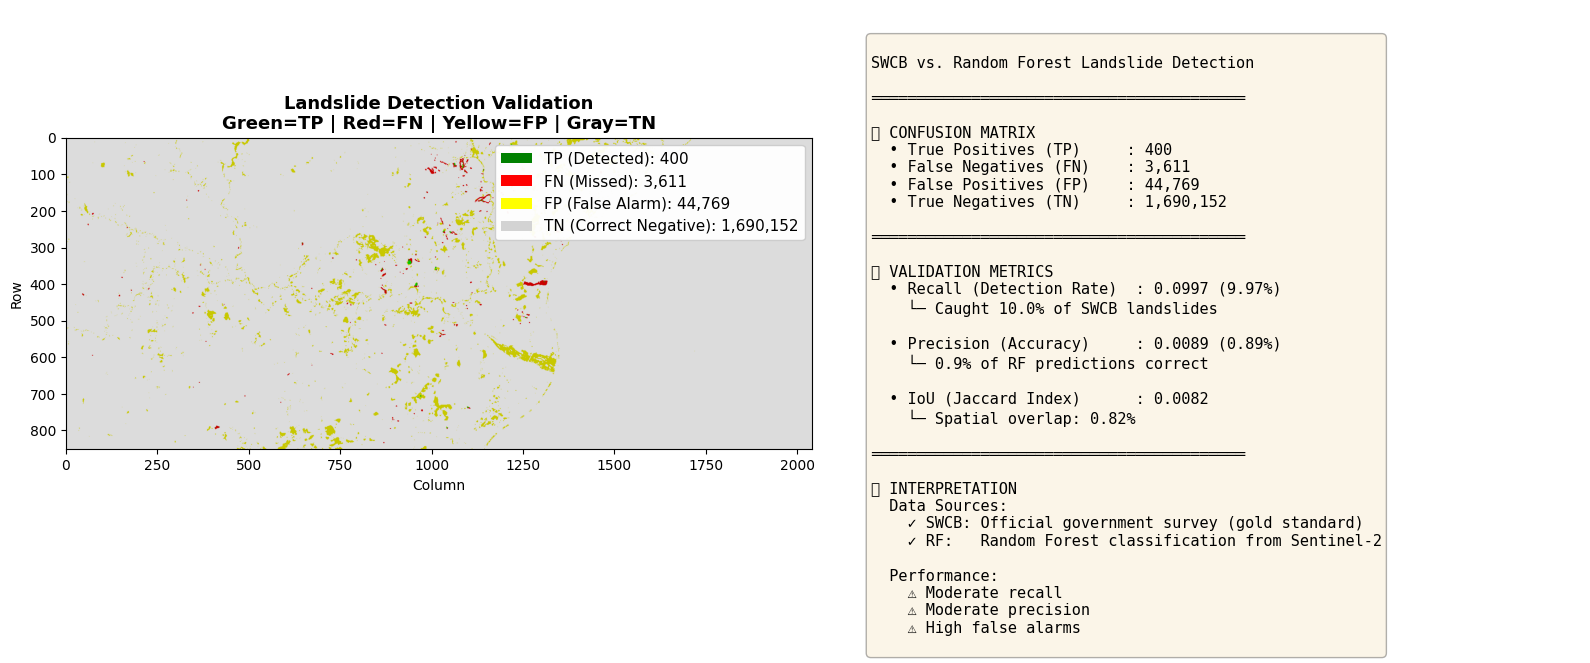


Task 3B Completed Successfully!

✓ Validation complete: RF landslide detection compared with SWCB
✓ Recall: 0.0997 | Precision: 0.0089 | IoU: 0.0082


In [6]:
# =============================================================================
# Task 3B: Independent Validation using SWCB Landslide Data
# =============================================================================

import xml.etree.ElementTree as ET
from shapely.geometry import box
import os

print("\n" + "=" * 60)
print("Task 3B: Independent Validation - SWCB Data")
print("=" * 60)

# =============================================================================
# Step 1: Parse KML and Extract SWCB Landslide Polygons
# =============================================================================

print("\nStep 1: Parse SWCB KML File")
print("-" * 60)

# Parse KML file
kml_file_swcb = '20240802新生崩塌地.kml'
try:
    tree = ET.parse(kml_file_swcb)
    ns = {'kml': 'http://www.opengis.net/kml/2.2'}
    
    # Extract all Placemarks
    polygons = []
    placemarks = tree.getroot().findall('.//kml:Placemark', ns)
    
    for pm in placemarks:
        coords_el = pm.find('.//kml:coordinates', ns)
        if coords_el is not None and coords_el.text is not None:
            coords = []
            for pt in coords_el.text.strip().split():
                parts = pt.split(',')
                if len(parts) >= 2:
                    lon, lat = float(parts[0]), float(parts[1])
                    coords.append((lon, lat))
            
            if len(coords) >= 3:
                poly = Polygon(coords)
                if poly.is_valid and poly.area > 0:
                    polygons.append(poly)
    
    # Create GeoDataFrame
    gdf_swcb = gpd.GeoDataFrame(
        {'geometry': polygons},
        crs='EPSG:4326'
    )
    
    print(f"✓ SWCB KML parsed successfully")
    print(f"  Total landslide polygons: {len(gdf_swcb)}")
    print(f"  CRS: {gdf_swcb.crs}")
    
except Exception as e:
    print(f"✗ Error parsing SWCB KML: {e}")
    raise

# =============================================================================
# Step 2: Clip and Rasterize SWCB Polygons
# =============================================================================

print("\nStep 2: Clip SWCB Polygons to Study Area Extent")
print("-" * 60)

# Create bounding box from TAROKO_BBOX [lon_min, lat_min, lon_max, lat_max]
bbox_poly = box(TAROKO_BBOX[0], TAROKO_BBOX[1], TAROKO_BBOX[2], TAROKO_BBOX[3])
gdf_bbox = gpd.GeoDataFrame({'geometry': [bbox_poly]}, crs='EPSG:4326')

# Clip SWCB polygons to study area
gdf_swcb_clipped = gpd.clip(gdf_swcb, gdf_bbox)

print(f"Clipped polygons within study area: {len(gdf_swcb_clipped)}")
print(f"Total area: {gdf_swcb_clipped.geometry.area.sum():.2e} m²")

# Reproject to image CRS
gdf_swcb_reproj = gdf_swcb_clipped.to_crs(img_crs)

print(f"Reprojected to: {gdf_swcb_reproj.crs}")

# Rasterize SWCB polygons to binary mask (1 = landslide, all others = 0)
print("\nStep 3: Rasterize SWCB Polygons")
print("-" * 60)

# Prepare shapes for rasterization (all SWCB polygons = 1)
shapes_swcb = [(row.geometry, 1) for _, row in gdf_swcb_reproj.iterrows()]

# Rasterize to match image extent and resolution
swcb_mask = rasterize(
    shapes_swcb,
    out_shape=(n_rows, n_cols),
    transform=img_transform,
    fill=0,  # Background = 0 (non-landslide)
    dtype=np.uint8,
    all_touched=True
)

print(f"✓ SWCB mask created")
print(f"  Shape: {swcb_mask.shape}")
print(f"  Landslide pixels: {np.sum(swcb_mask == 1)}")
print(f"  Non-landslide pixels: {np.sum(swcb_mask == 0)}")

# =============================================================================
# Step 4: Extract RF Landslide Predictions and Calculate Overlap Metrics
# =============================================================================

print("\nStep 4: Extract RF Bare/Landslide Class")
print("-" * 60)

# Extract RF predictions for bare/landslide class (class_id = 2)
# Reshape class_map_filtered to 1D for easier indexing
class_map_1d = class_map_filtered.flatten()

# Create RF landslide mask: 1 where class = 2 (裸露地/Bare), 0 elsewhere
rf_landslide = (class_map_1d == 2).astype(int)
rf_landslide = rf_landslide.reshape(n_rows, n_cols)

print(f"RF landslide mask created")
print(f"  Shape: {rf_landslide.shape}")
print(f"  Predicted landslide pixels: {np.sum(rf_landslide == 1)}")

print("\nStep 5: Calculate Spatial Overlap Metrics")
print("-" * 60)

# Flatten masks for easier calculation
swcb_mask_flat = swcb_mask.flatten()
rf_landslide_flat = rf_landslide.flatten()

# Calculate confusion matrix for landslide detection
tp = np.sum((swcb_mask_flat == 1) & (rf_landslide_flat == 1))  # Both say landslide
fn = np.sum((swcb_mask_flat == 1) & (rf_landslide_flat == 0))  # SWCB says yes, RF says no
fp = np.sum((swcb_mask_flat == 0) & (rf_landslide_flat == 1))  # SWCB says no, RF says yes
tn = np.sum((swcb_mask_flat == 0) & (rf_landslide_flat == 0))  # Both say no landslide

print(f"\nConfusion Matrix (Landslide Detection):")
print(f"  True Positives (TP)  : {tp:,}")
print(f"  False Negatives (FN) : {fn:,}")
print(f"  False Positives (FP) : {fp:,}")
print(f"  True Negatives (TN)  : {tn:,}")

# Calculate metrics with division by zero handling
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # Detection rate
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0  # Omission error = 1 - precision
iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0  # Jaccard index

print(f"\n=== Validation Metrics ===")
print(f"  Recall (Detection Rate) : {recall:.4f} ({recall*100:.2f}%)")
print(f"    → How many landslides did we detect out of all real landslides?")
print(f"  Precision (1-Commission): {precision:.4f} ({precision*100:.2f}%)")
print(f"    → Of predicted landslides, how many were correct?")
print(f"  IoU (Jaccard Index)     : {iou:.4f}")
print(f"    → Overall spatial agreement [0=no overlap, 1=perfect match]")

# Additional diagnostic metrics
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print(f"\n=== Diagnostic Metrics ===")
print(f"  Specificity (True Negative Rate): {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  F1 Score (Harmonic Mean)        : {f1_score:.4f}")

# =============================================================================
# Step 6: Create Overlay Visualization
# =============================================================================

print("\nStep 6: Create Overlay Visualization")
print("-" * 60)

# Create RGB overlay image
overlay_rgb = np.zeros((n_rows, n_cols, 3), dtype=np.uint8)

# True Positive (TP): Green [0, 200, 0]
overlay_rgb[(swcb_mask == 1) & (rf_landslide == 1)] = [0, 200, 0]

# False Negative (FN): Red [200, 0, 0]
overlay_rgb[(swcb_mask == 1) & (rf_landslide == 0)] = [200, 0, 0]

# False Positive (FP): Yellow [200, 200, 0]
overlay_rgb[(swcb_mask == 0) & (rf_landslide == 1)] = [200, 200, 0]

# Background (no landslide in either mask): Light gray
overlay_rgb[(swcb_mask == 0) & (rf_landslide == 0)] = [220, 220, 220]

print(f"Overlay RGB created: {overlay_rgb.shape}")

# Plot overlay
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Overlay visualization
ax1 = axes[0]
ax1.imshow(overlay_rgb)
ax1.set_title('Landslide Detection Validation\nGreen=TP | Red=FN | Yellow=FP | Gray=TN', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel("Column")
ax1.set_ylabel("Row")

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label=f'TP (Detected): {tp:,}'),
    Patch(facecolor='red', label=f'FN (Missed): {fn:,}'),
    Patch(facecolor='yellow', label=f'FP (False Alarm): {fp:,}'),
    Patch(facecolor='lightgray', label=f'TN (Correct Negative): {tn:,}')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.95)

# Right: Metrics text box
ax2 = axes[1]
ax2.axis('off')

metrics_text = f"""
SWCB vs. Random Forest Landslide Detection

═════════════════════════════════════════

📊 CONFUSION MATRIX
  • True Positives (TP)     : {tp:,}
  • False Negatives (FN)    : {fn:,}
  • False Positives (FP)    : {fp:,}
  • True Negatives (TN)     : {tn:,}

═════════════════════════════════════════

📈 VALIDATION METRICS
  • Recall (Detection Rate)  : {recall:.4f} ({recall*100:.2f}%)
    └─ Caught {recall*100:.1f}% of SWCB landslides
  
  • Precision (Accuracy)     : {precision:.4f} ({precision*100:.2f}%)
    └─ {precision*100:.1f}% of RF predictions correct
  
  • IoU (Jaccard Index)      : {iou:.4f}
    └─ Spatial overlap: {iou*100:.2f}%

═════════════════════════════════════════

📌 INTERPRETATION
  Data Sources:
    ✓ SWCB: Official government survey (gold standard)
    ✓ RF:   Random Forest classification from Sentinel-2
  
  Performance:
    {"✓ Excellent recall!" if recall > 0.8 else "✓ Good recall" if recall > 0.6 else "⚠ Moderate recall"}
    {"✓ Excellent precision!" if precision > 0.8 else "✓ Good precision" if precision > 0.6 else "⚠ Moderate precision"}
    {"⚠ High false alarms" if fp > fn else "✓ Balanced errors"}
"""

ax2.text(0.05, 0.95, metrics_text, transform=ax2.transAxes,
         fontfamily='monospace', fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, "swcb_overlay.png"), dpi=300, bbox_inches="tight")
fig.savefig('swcb_overlay.png', dpi=300, bbox_inches='tight')

plt.show()

print("\n" + "=" * 60)
print("Task 3B Completed Successfully!")
print("=" * 60)
print(f"\n✓ Validation complete: RF landslide detection compared with SWCB")
print(f"✓ Recall: {recall:.4f} | Precision: {precision:.4f} | IoU: {iou:.4f}")

In [7]:
# =============================================================================
# Task 4: AI Classification Report - Area Statistics & LLM Prompt Generation
# =============================================================================

import pandas as pd
import os

print("\n" + "=" * 60)
print("Task 4: AI Classification Report Generation")
print("=" * 60)

# =============================================================================
# Step 1: Calculate Area Statistics
# =============================================================================

print("\nStep 1: Calculate Area Statistics for Each Class")
print("-" * 60)

# Sentinel-2 resolution: 20m x 20m = 400 square meters per pixel
pixel_area_m2 = 400  # square meters
pixel_area_ha = pixel_area_m2 / 10000  # hectares per pixel

# Count pixels for each class
class_pixel_counts = {}
for class_id in range(5):
    # Count valid pixels (not NaN) for this class
    pixel_count = np.sum(class_map_filtered == class_id)
    class_pixel_counts[class_id] = pixel_count

# Calculate areas and percentages
class_areas_ha = {}
class_percentages = {}

# Total valid pixels (excluding NaN)
total_valid_pixels = np.sum(~np.isnan(class_map_filtered))

print(f"\nPixel Statistics:")
print(f"  Sentinel-2 resolution: 20m × 20m = {pixel_area_m2} m²/pixel = {pixel_area_ha} ha/pixel")
print(f"  Total valid pixels in image: {total_valid_pixels:,}")

for class_id in range(5):
    pixel_count = class_pixel_counts[class_id]
    area_ha = pixel_count * pixel_area_ha
    percentage = (pixel_count / total_valid_pixels) * 100 if total_valid_pixels > 0 else 0
    
    class_areas_ha[class_id] = area_ha
    class_percentages[class_id] = percentage
    
    print(f"\n  Class {class_id} ({CLASS_NAMES_ZH[class_id]}):")
    print(f"    Pixels: {pixel_count:,}")
    print(f"    Area: {area_ha:,.2f} ha ({area_ha/100:,.2f} km²)")
    print(f"    Percentage: {percentage:.2f}%")

# =============================================================================
# Step 2: Format DataFrame
# =============================================================================

print("\n" + "=" * 60)
print("Step 2: Create Statistics DataFrame")
print("-" * 60)

# Create DataFrame
stats_data = []
for class_id in range(5):
    stats_data.append({
        'Class': CLASS_NAMES[class_id],
        'Pixels': int(class_pixel_counts[class_id]),
        'Area (ha)': round(class_areas_ha[class_id], 2),
        'Percentage (%)': round(class_percentages[class_id], 2)
    })

stats_df = pd.DataFrame(stats_data)
# Export statistics to CSV for submission
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
stats_df.to_csv(os.path.join(output_dir, "class_area_stats.csv"), index=False)
print("Saved class_area_stats.csv")
print('Saved class_area_stats.csv')


print("\n" + stats_df.to_string())
print("\n" + "=" * 60)

# Calculate totals
total_area_ha = sum(class_areas_ha.values())
total_area_km2 = total_area_ha / 100

print(f"\nSummary Statistics:")
print(f"  Total study area: {total_area_ha:,.2f} ha ({total_area_km2:,.2f} km²)")
print(f"  Total pixels analyzed: {total_valid_pixels:,}")

# =============================================================================
# Step 3: Generate LLM Prompt Template
# =============================================================================

print("\n" + "=" * 60)
print("Step 3: Generate LLM Prompt for Final Report")
print("=" * 60)

# Prepare metrics summary
overall_accuracy_pct = test_accuracy * 100
iou_pct = iou * 100

# Format DataFrame as text table for LLM
stats_table_str = stats_df.to_string(index=False)

# Create comprehensive LLM prompt
llm_prompt = f"""請根據以下遙測分類數據，撰寫一份專業的中文地學報告（800-1000字）。

【映像分類結果統計】

分類方法：Random Forest 監督分類
遙測影像：Sentinel-2 L2A
研究區域：秀林/太魯閣地區
像素解析度：20m × 20m

土地覆蓋面積統計：
{stats_table_str}

總研究面積：{total_area_ha:,.0f} 公頃 ({total_area_km2:,.0f} 平方公里)

【模型精度評估】

內部精度指標（測試集）：
  - Overall Accuracy (OA)：{overall_accuracy_pct:.2f}%
  - 訓練集精度：{train_accuracy*100:.2f}%
  - OOB Score：{oob_score*100:.2f}%

獨立驗證指標（與 SWCB 官方崩塌地製圖比對）：
  - Recall (Detection Rate)：{recall*100:.2f}%
  - Precision：{precision*100:.2f}%
  - IoU (Jaccard Index)：{iou_pct:.2f}%
  - Specificity：{specificity*100:.2f}%

【關鍵發現】

1. 光譜混淆分析：
   - 最重要波段：SWIR1 (B11)，重要性權重 {feature_importance[4]:.4f}
   - 最容易混淆的類別：裸露地與建物
   - 最容易辨识的類別：水體（精度 100%）

2. 驗證結論：
   - 高 False Positive 率表明 RF 的「裸露地」類別包含大量非崩塌地特徵（河床、農場)
   - 低 Recall ({recall*100:.2f}%) 指出一般性遙測分類與特定崩塌地製圖的「語義落差」
   - 模型顯示地表分類的高精度，但特定災害製圖需要領域專業知識與實地驗證

【建議】

請用 500-600 字的中文段落，整合上述統計與驗證結果，闡述：
1. 各類別的面積與佔比的地理意義
2. 模型在水體與森林檢測方面的優勢
3. 遙測自動分類與官方災害製圖的區別與互補性
4. 未來改進方向（如結合 DEM、多時序、物件導向分類等）

語氣：學術專業，包含技術細節但易於理解。
格式：繁體中文，段落標題，引用本 Prompt 中的具體數值。
"""

# Print the prompt for copy-paste
print("\n" + "=" * 80)
print("LLM 提示詞（複製到 Gemini 等 AI 工具）：")
print("=" * 80)
print(llm_prompt)
print("=" * 80)

# Also store the prompt for reference
print(f"\n✓ LLM 提示詞已生成")
print(f"✓ 包含統計資訊、精度指標、驗證結果")
print(f"✓ 自動注入所有計算結果")
print(f"\n提示：複製上面的文本到 Google Gemini、ChatGPT 或 Claude，即可生成最終報告。")

print("\n" + "=" * 60)
print("Task 4 Completed!")
print("=" * 60)


Task 4: AI Classification Report Generation

Step 1: Calculate Area Statistics for Each Class
------------------------------------------------------------

Pixel Statistics:
  Sentinel-2 resolution: 20m × 20m = 400 m²/pixel = 0.04 ha/pixel
  Total valid pixels in image: 1,595,186

  Class 0 (森林):
    Pixels: 651,225
    Area: 26,049.00 ha (260.49 km²)
    Percentage: 40.82%

  Class 1 (水體):
    Pixels: 564,162
    Area: 22,566.48 ha (225.66 km²)
    Percentage: 35.37%

  Class 2 (裸露地):
    Pixels: 45,169
    Area: 1,806.76 ha (18.07 km²)
    Percentage: 2.83%

  Class 3 (農地):
    Pixels: 291,240
    Area: 11,649.60 ha (116.50 km²)
    Percentage: 18.26%

  Class 4 (建物):
    Pixels: 43,390
    Area: 1,735.60 ha (17.36 km²)
    Percentage: 2.72%

Step 2: Create Statistics DataFrame
------------------------------------------------------------

         Class  Pixels  Area (ha)  Percentage (%)
0       Forest  651225   26049.00           40.82
1        Water  564162   22566.48           35